In [34]:
from google.colab import drive
# drive.mount('/content/drive')  # descomentar solo en Google Colab

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Carga de las tres pestañas del Excel con los nombres correctos
df_usuarios = pd.read_excel('PD-Base_Sucia.xlsx', sheet_name='Usuarios')
df_asistencias = pd.read_excel('PD-Base_Sucia.xlsx', sheet_name='Asistencias')
df_actividades = pd.read_excel('PD-Base_Sucia.xlsx', sheet_name='Actividades')

print("Padrón de usuarios cargado:", df_usuarios.shape)
print("Registros de asistencia cargados:", df_asistencias.shape)
print("Catálogo de actividades cargado:", df_actividades.shape)

In [36]:
# This cell is no longer needed as df_actividades is now loaded in cell 57a4f813.

**Limpieza de DNIs (Clave Primaria)**

In [37]:
def limpiar_dni(dni):
    if pd.isna(dni) or str(dni).strip() == "":
        return "SIN_DNI" # Bandera de control para casos críticos [13, 14]
    # Quitamos puntos y espacios
    return str(dni).replace(".", "").replace(" ", "").strip()

df_usuarios['dni_limpio'] = df_usuarios['dni'].apply(limpiar_dni)

La función `limpiar_dni` está diseñada para estandarizar los números de identificación (DNI) en el DataFrame `df_usuarios`. Realiza las siguientes acciones:

*   **Manejo de valores nulos o vacíos:** Si un DNI es nulo (`pd.isna(dni)`) o consiste solo en espacios en blanco (`str(dni).strip() == ""`), la función devuelve la cadena "SIN_DNI". Esta es una bandera de control para identificar fácilmente los registros sin un DNI válido.
*   **Eliminación de caracteres no deseados:** Para el resto de los DNIs, la función convierte el valor a una cadena de texto (`str(dni)`), luego elimina cualquier punto (`.`) y espacio (` `) que pueda estar presente en el número.
*   **Eliminación de espacios extra:** Finalmente, utiliza `.strip()` para eliminar cualquier espacio en blanco al principio o al final de la cadena resultante.

El resultado es una columna `dni_limpio` en `df_usuarios` que contiene los DNIs en un formato limpio y uniforme, facilitando su uso para análisis o fusiones de datos.

In [ ]:
display(df_usuarios[['dni', 'dni_limpio']].head(10))

**Normalización de Nombres
Para resolver los duplicados tipográficos (ej. "Juan Perez" vs "Juan Peres")**

In [39]:
import unicodedata

def normalizar_texto(texto):
    if pd.isna(texto): return ""
    texto = str(texto).upper().strip()
    # Eliminar acentos
    texto = "".join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')
    return texto

df_usuarios['nombre'] = df_usuarios['nombre'].apply(normalizar_texto)
df_usuarios['apellido'] = df_usuarios['apellido'].apply(normalizar_texto)

La función `normalizar_texto` se utiliza para estandarizar cadenas de texto, específicamente los nombres y apellidos, para evitar duplicados causados por diferencias de formato o acentuación. Realiza los siguientes pasos:

1.  **Manejo de valores nulos:** Si el valor de entrada es nulo (`pd.isna(texto)`), devuelve una cadena vacía.
2.  **Conversión a mayúsculas y eliminación de espacios:** Convierte el texto a mayúsculas (`str(texto).upper()`) y elimina los espacios en blanco al principio y al final (`.strip()`).
3.  **Eliminación de acentos:** Utiliza la librería `unicodedata` para eliminar los caracteres diacríticos (acentos) de la cadena, asegurando que, por ejemplo, "María" y "Maria" sean tratados como el mismo valor.

Al aplicar esta función a las columnas 'nombre' y 'apellido', se busca limpiar y unificar estos datos para mejorar la consistencia y facilitar búsquedas y uniones.

In [ ]:
print("Primeras 10 filas con nombres y apellidos normalizados:")
display(df_usuarios[['nombre', 'apellido']].head(10))

**el siguiente paso lógico es realizar la unificación masiva y generar las primeras visualizaciones del EDA (Análisis Exploratorio de Datos).**

 Unificación Masiva (Merge)
Debemos vincular los 5.000 registros de asistencia con el padrón de 500 usuarios. Usaremos la columna id_usuario

In [ ]:
# Unificamos las tablas (Asistencias + Datos de Usuarios)
df_unificado = pd.merge(df_asistencias, df_usuarios, on='id_usuario', how='left')

# Verificamos cuántos registros quedaron sin DNI o con datos faltantes tras el cruce
print(f"Total de registros unificados: {len(df_unificado)}")

In [ ]:
import pandas as pd
# Unificamos con el catálogo de actividades para obtener los nombres
df_unificado = pd.merge(df_unificado, df_actividades, on='id_actividad', how='left')
# Renombramos la columna 'actividad' a 'nombre_actividad' para claridad y consistencia
if 'actividad' in df_unificado.columns:
    df_unificado = df_unificado.rename(columns={'actividad': 'nombre_actividad'})

print("Columns in df_unificado after merging and renaming:")
print(df_unificado.columns)

**Análisis Exploratorio (EDA): Gráfico de Asistencias por Mes**

/tmp/ipykernel_3368/1132598677.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_unificado['fecha'] = pd.to_datetime(df_unificado['fecha'], errors='coerce')


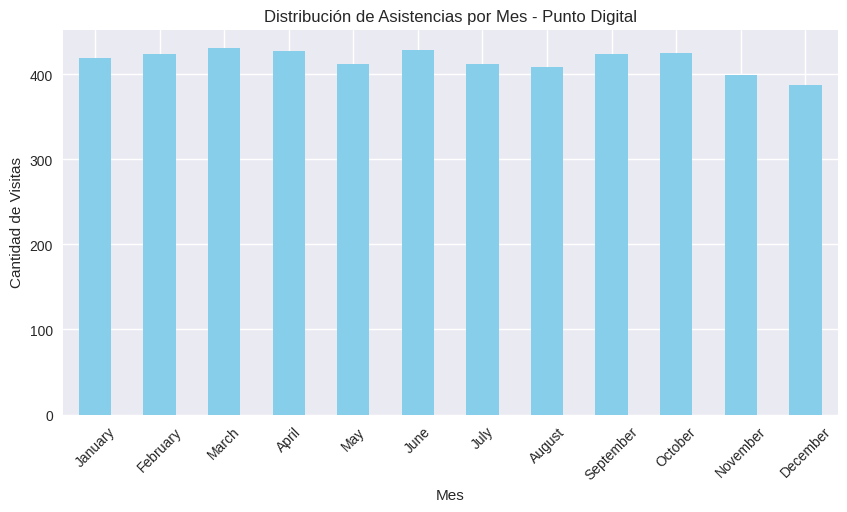

In [43]:
import matplotlib.pyplot as plt

# Convertimos la columna 'fecha' a tipo datetime
df_unificado['fecha'] = pd.to_datetime(df_unificado['fecha'], errors='coerce')

# Extraemos el mes de la fecha
df_unificado['mes'] = df_unificado['fecha'].dt.month_name()

# Contamos asistencias por mes
asistencias_por_mes = df_unificado['mes'].value_counts().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])

# Creamos el gráfico
plt.figure(figsize=(10, 5))
asistencias_por_mes.plot(kind='bar', color='skyblue')
plt.title('Distribución de Asistencias por Mes - Punto Digital')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Visitas')
plt.xticks(rotation=45)
plt.show()

**EDA: Top 10 de Actividades/Talleres**

In [ ]:
import matplotlib.pyplot as plt

# Ahora utilizamos 'nombre_actividad' para el conteo
top_actividades = df_unificado['nombre_actividad'].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_actividades.plot(kind='pie', autopct='%1.1f%%', cmap='viridis')
plt.title('Top 10 Actividades con Mayor Demanda')
plt.ylabel('')
plt.show()

**Generación del "Reporte de Casos Críticos"**

In [ ]:
# Filtramos registros que quedaron con fecha inválida (NaT) o sin DNI
casos_criticos = df_unificado[(df_unificado['fecha'].isna()) | (df_unificado['dni_limpio'] == "SIN_DNI")]

# Exportamos para validar con Mario Feijoo
casos_criticos.to_csv('reporte_casos_criticos_ODA.csv', index=False)
print(f"Se han exportado {len(casos_criticos)} casos críticos para revisión manual.")

## Explicación de los Casos Críticos

El DataFrame `casos_criticos` contiene registros que han sido identificados como problemáticos durante el proceso de limpieza y unificación de datos. Específicamente, estos son los registros donde:

1.  **La `fecha` es inválida (`NaT`)**: Esto significa que al intentar convertir la columna `fecha` a un formato de fecha y hora, algunos valores no pudieron ser interpretados correctamente y resultaron en 'Not a Time' (`NaT`). Esto suele ocurrir debido a entradas de fecha inconsistentes o mal formadas en los datos originales.
2.  **El `dni_limpio` es "SIN_DNI"**: Esto indica que el valor original del DNI era nulo, estaba vacío o contenía solo espacios, y por lo tanto, nuestra función `limpiar_dni` lo marcó como "SIN_DNI" para señalar un DNI faltante o inutilizable.

Estos casos se consideran 'críticos' porque carecen de información esencial (una fecha o un DNI válidos) que es crucial para un análisis preciso o para vincular registros de manera efectiva. El reporte fue generado para una revisión manual por parte de Mario Feijoo con el fin de investigar y, si es posible, corregir estos problemas.

In [ ]:
display(casos_criticos)

** Exportar a Excel (.xlsx) en tu Google Drive**

In [48]:
# Definimos la ruta de salida en tu Drive
ruta_excel = 'Base_Maestra_PuntoDigital_Limpia.xlsx'

# Exportamos el DataFrame unificado a Excel
df_unificado.to_excel(ruta_excel, index=False)
print(f"¡Éxito! El archivo se ha guardado en tu Drive como: {ruta_excel}")

¡Éxito! El archivo se ha guardado en tu Drive como: /content/drive/My Drive/Base_Maestra_PuntoDigital_Limpia.xlsx


** Exportar directamente a Google Sheets (API)**

In [49]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()
gc = gspread.authorize(creds)

# 1. Creamos una nueva hoja de cálculo en tu Drive
sh = gc.create('PuntoDigital_Base_Maestra_Automatizada')

# 2. Seleccionamos la primera pestaña
worksheet = sh.get_worksheet(0)

# 3. Convertimos el DataFrame a una lista de listas para subirlo
# Pandas maneja los NaT/NaN, pero gspread necesita strings para celdas vacías
df_exportar = df_unificado.astype(str).replace('NaT', '').replace('nan', '')

# 4. Subimos los datos (encabezados + filas)
worksheet.update([df_exportar.columns.values.tolist()] + df_exportar.values.tolist())

print("¡Proceso completado! Ya puedes ver tu Google Sheet con los 5.000 registros unificados.")
print(f"Puedes acceder a tu Google Sheet aquí: {sh.url}")

¡Proceso completado! Ya puedes ver tu Google Sheet con los 5.000 registros unificados.
Puedes acceder a tu Google Sheet aquí: https://docs.google.com/spreadsheets/d/1hKVTsHLZE04XAd9m5iIo79e2Mbjr7a8L05CmFiqY_yE


dashboard

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo visual
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Dashboard Analítico - Punto Digital ODA (Vista Preliminar)', fontsize=20)

# 1. Gráfico de Asistencias por Mes (Evolución Temporal)
# Ensure 'fecha' column is datetime type
df_unificado['fecha'] = pd.to_datetime(df_unificado['fecha'], errors='coerce')
df_unificado['mes'] = df_unificado['fecha'].dt.month_name()
meses_ordenados = ['January', 'February', 'March', 'April', 'May', 'June',
                   'July', 'August', 'September', 'October', 'November', 'December']
asistencias_mes = df_unificado['mes'].value_counts().reindex(meses_ordenados)

asistencias_mes.plot(kind='line', marker='o', ax=axes[0, 0], color='blue') # Specify subplot axes[0,0]
axes[0, 0].set_title('Evolución Mensual de Visitas')
axes[0, 0].set_ylabel('Cantidad de Asistencias')

# 2. Top 10 Actividades con más demanda (usando nombre_actividad)
top_actividades = df_unificado['nombre_actividad'].value_counts().head(10)
top_actividades.plot(kind='barh', ax=axes[0, 1], color='green') # Specify subplot axes[0,1]
axes[0, 1].set_title('Top 10 Actividades/Talleres')
axes[0, 1].invert_yaxis()

# 3. Distribución por Localidad (Alcance Geográfico)
localidades = df_unificado['localidad'].value_counts().head(5)
localidades.plot(kind='pie', autopct='%1.1f%%', ax=axes[1, 0], startangle=90) # Specify subplot axes[1,0]
axes[1, 0].set_title('Distribución por Localidad')
axes[1, 0].set_ylabel('')

# 4. Resumen de Métricas Clave (KPIs)
axes[1, 1].axis('off') # Specify subplot axes[1,1]
axes[1, 1].text(0.5, 0.7, f"Total Asistencias: {len(df_unificado)}",
                fontsize=18, ha='center', fontweight='bold')
axes[1, 1].text(0.5, 0.4, f"Usuarios Únicos: {df_unificado['id_usuario'].nunique()}",
                fontsize=18, ha='center', fontweight='bold')
axes[1, 1].text(0.5, 0.1, f"Casos Críticos: {len(df_unificado[df_unificado['dni_limpio'] == 'SIN_DNI'])}",
                fontsize=14, ha='center', color='red')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [52]:
import pandas as pd
# 2. Top 10 Actividades con más demanda (usando nombre_actividad)
top_actividades = df_unificado['nombre_actividad'].value_counts().head(10)
top_actividades.plot(kind='barh', ax=axes[0, 1], color='green') # Specify subplot axes[0,1]
axes[0, 1].set_title('Top 10 Actividades/Talleres')
axes[0, 1].invert_yaxis()